# Noninteracting band comparison

Plot the two central bands of Bernal bilayer graphene along
$k_y=0$ near the $K$ valley for layer energy biases
$D=0,50,100$ meV.

The Hamiltonian retains all four bands; only the two central
bands are displayed in this energy window.

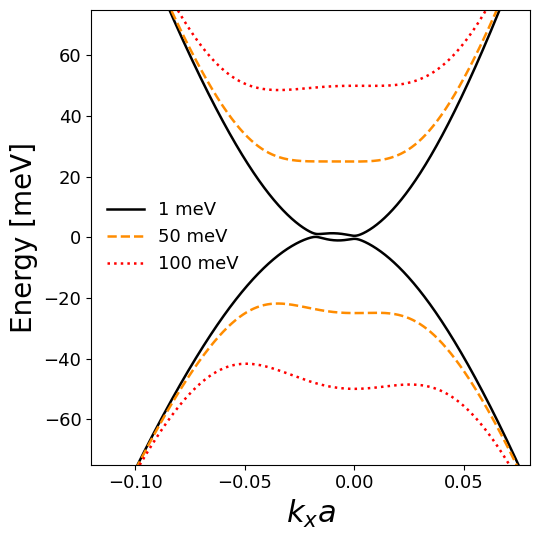

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
from bernal_initializer import Parameters, hamiltonian

# Use the paper's parameters without changing the initialization settings
p_base = Parameters()

# Dimensionless horizontal coordinate: x = k_x a, with k_y = 0
x = np.linspace(-0.12, 0.08, 1001)
k_line = np.column_stack((
    x / p_base.a_angstrom,
    np.zeros_like(x)
))

fig, ax = plt.subplots(figsize=(5.5, 5.5))

# Layer energy biases in meV, with corresponding plotting styles
styles = [
    (1,   "black",      "-"),
    (50,  "darkorange", "--"),
    (100, "red",        ":"),
]

for D_meV, color, linestyle in styles:
    p = replace(p_base, D_eV=D_meV / 1000)

    # Diagonalize all four bands and convert energies from eV to meV
    energies = 1000 * np.linalg.eigvalsh(
        hamiltonian(k_line, valley=+1, parameters=p)
    )

    # Display only the two central bands
    ax.plot(x, energies[:, 1], color=color,
            linestyle=linestyle, lw=1.8,
            label=f"{D_meV} meV")
    ax.plot(x, energies[:, 2], color=color,
            linestyle=linestyle, lw=1.8)

ax.set_xlabel(r"$k_x a$", fontsize=22)
ax.set_ylabel("Energy [meV]", fontsize=20)
ax.set_xlim(-0.12, 0.08)
ax.set_ylim(-75, 75)
ax.set_xticks([-0.10, -0.05, 0.00, 0.05])
ax.set_yticks(np.arange(-60, 61, 20))
ax.tick_params(labelsize=13)
ax.legend(loc="center left", frameon=False, fontsize=13)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from bernal_initializer import Parameters, hamiltonian

p_base = Parameters()

# Momentum cut: x = k_x a, with k_y = 0
x = np.linspace(-0.12, 0.08, 401)
k_line = np.column_stack((
    x / p_base.a_angstrom,
    np.zeros_like(x)
))

# Sweep D from 0 to 100 meV in 51 frames
D_values = np.linspace(0, 100, 30)

# Precompute the two central bands for every frame
bands = []
for D_meV in D_values:
    p = replace(p_base, D_eV=D_meV / 1000)
    energies = 1000 * np.linalg.eigvalsh(
        hamiltonian(k_line, valley=+1, parameters=p)
    )
    bands.append(energies[:, 1:3])

bands = np.asarray(bands)  # Shape: (frame, momentum, band)

# Set up the figure
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=90)

valence, = ax.plot(x, bands[0, :, 0], color="darkorange",
                  lw=2, label="Valence")
conduction, = ax.plot(x, bands[0, :, 1], color="royalblue",
                     lw=2, label="Conduction")

title = ax.set_title("")

ax.set_xlabel(r"$k_x a$", fontsize=20)
ax.set_ylabel("Energy [meV]", fontsize=18)
ax.set_xlim(-0.12, 0.08)
ax.set_ylim(-75, 75)
ax.set_xticks([-0.10, -0.05, 0.00, 0.05])
ax.set_yticks(np.arange(-60, 61, 20))
ax.legend(loc="center left", frameon=False)
plt.tight_layout()

# Update the existing curves without recalculating the spectrum
def update(frame):
    valence.set_ydata(bands[frame, :, 0])
    conduction.set_ydata(bands[frame, :, 1])
    title.set_text(fr"$D = {D_values[frame]:.0f}$ meV")
    return valence, conduction, title

animation = FuncAnimation(
    fig,
    update,
    frames=len(D_values),
    interval=100,  # Milliseconds between frames
    repeat=True
)

plt.close(fig)  # Avoid displaying an extra static figure
display(HTML(animation.to_jshtml()))